In [1]:
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("MNE version:", mne.__version__)

MNE version: 1.13.2


In [2]:
DATA_ROOT = Path(r"C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148")

print("Dataset exists:", DATA_ROOT.exists())
print("Dataset path:", DATA_ROOT)               

Dataset exists: True
Dataset path: C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148


In [3]:
vhdr_files = sorted(
    DATA_ROOT.glob(
        "sub-01/ses-session1/eeg/*task-memory_eeg.vhdr"
    )
)

print("Found:", len(vhdr_files))

for file in vhdr_files:
    print(file)

Found: 1
C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr


In [6]:
vhdr_file = vhdr_files[0]

raw = mne.io.read_raw_brainvision(
    vhdr_file,
    preload=True
)

print(raw)

Extracting parameters from C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148\sub-01\ses-session1\eeg\sub-01_ses-session1_task-memory_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 149999  =      0.000 ...   299.998 secs...
<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 61 x 150000 (300.0 s), ~69.9 MiB, data loaded>


In [7]:
TARGET_CHANNELS = ["Fp1", "Fp2", "Fz"]

missing = [
    ch for ch in TARGET_CHANNELS
    if ch not in raw.ch_names
]

if missing:
    raise ValueError(f"Missing channels: {missing}")

raw_3ch = raw.copy().pick(TARGET_CHANNELS)

print(raw_3ch)
print("Channels:", raw_3ch.ch_names)

<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 3 x 150000 (300.0 s), ~3.4 MiB, data loaded>
Channels: ['Fp1', 'Fp2', 'Fz']


In [8]:
original_sfreq = raw_3ch.info["sfreq"]
original_duration = raw_3ch.times[-1]

print("Sampling frequency:", original_sfreq)
print("Duration:", original_duration)
print("Channels:", raw_3ch.ch_names)

Sampling frequency: 500.0
Duration: 299.998
Channels: ['Fp1', 'Fp2', 'Fz']


Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


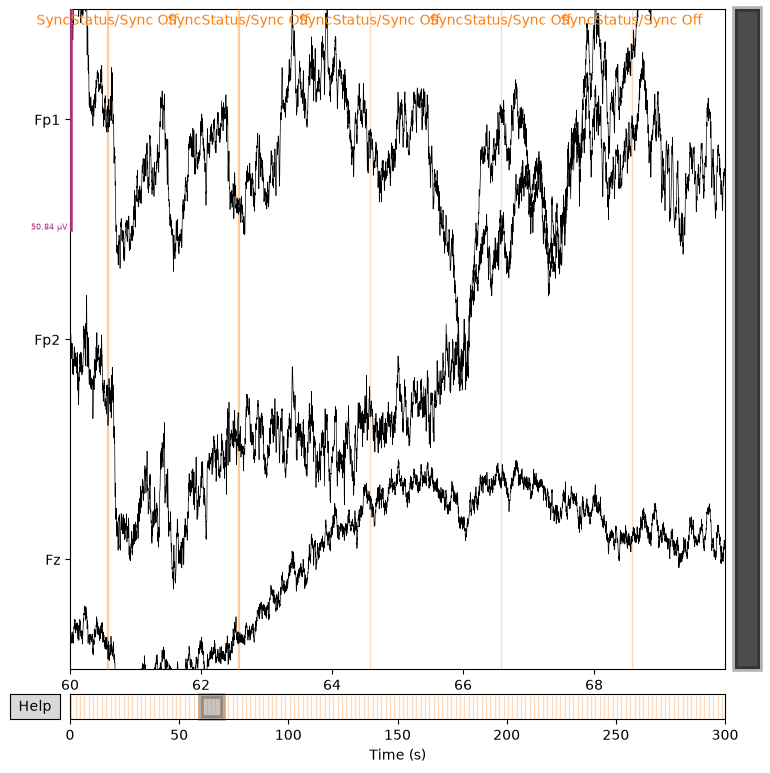

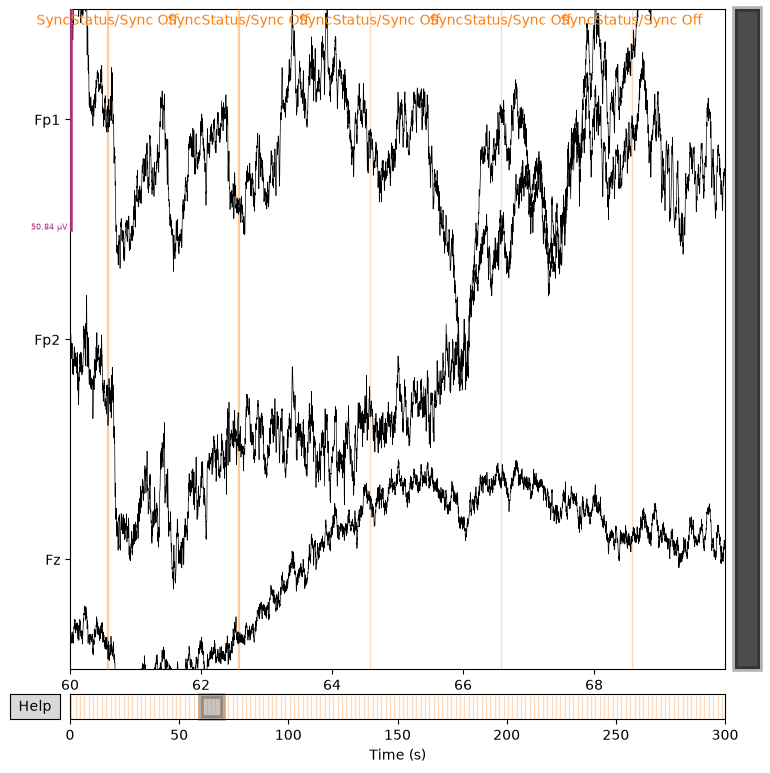

In [9]:
raw_3ch.plot(
    duration=10,
    start=60,
    n_channels=3,
    scalings="auto",
    title="Raw EEG — Fp1 / Fp2 / Fz"
)

In [10]:
filtered = raw_3ch.copy()

In [11]:
filtered.filter(
    l_freq=0.3,
    h_freq=45.0,
    fir_design="firwin"
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 5501 samples (11.002 s)



<RawBrainVision | sub-01_ses-session1_task-memory_eeg.eeg, 3 x 150000 (300.0 s), ~3.4 MiB, data loaded>

In [12]:
print(
    "Filtered frequency range:",
    filtered.info["highpass"],
    "Hz →",
    filtered.info["lowpass"],
    "Hz"
)

Filtered frequency range: 0.3 Hz → 45.0 Hz


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


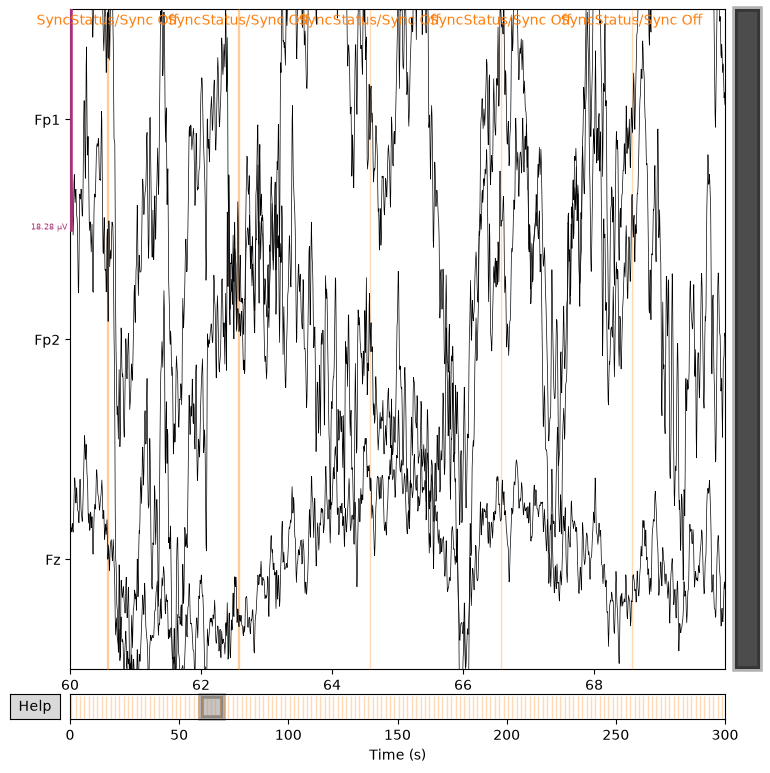

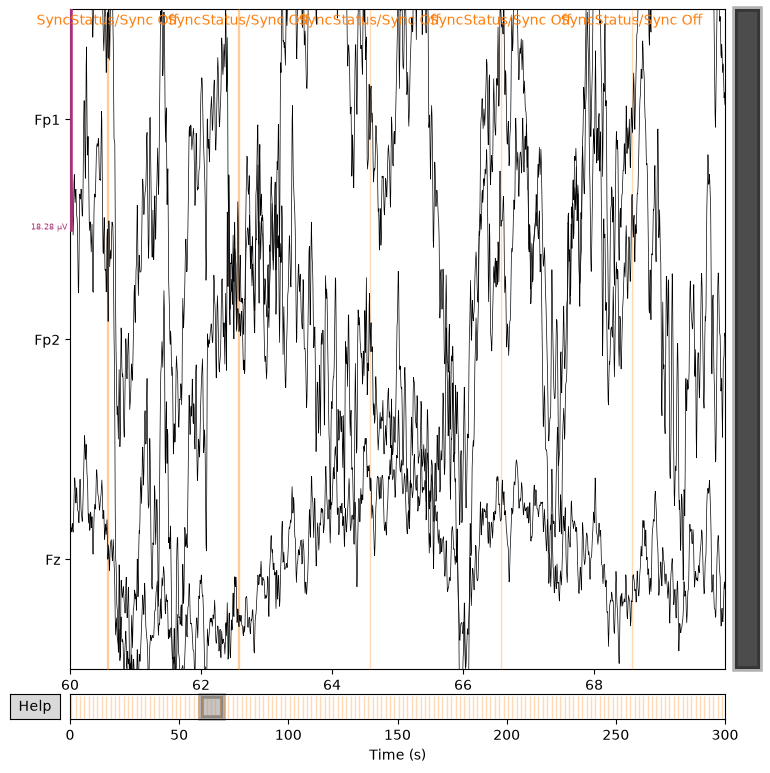

In [13]:
filtered.plot(
    duration=10,
    start=60,
    n_channels=3,
    scalings="auto",
    title="Filtered EEG — 0.3–45 Hz"
)

In [14]:
raw_data_uv = raw_3ch.get_data() * 1e6
filtered_data_uv = filtered.get_data() * 1e6

for i, ch in enumerate(TARGET_CHANNELS):
    print(f"\n{ch}")

    print(
        f"Raw:      "
        f"min={raw_data_uv[i].min():.2f} µV, "
        f"max={raw_data_uv[i].max():.2f} µV, "
        f"std={raw_data_uv[i].std():.2f} µV"
    )

    print(
        f"Filtered: "
        f"min={filtered_data_uv[i].min():.2f} µV, "
        f"max={filtered_data_uv[i].max():.2f} µV, "
        f"std={filtered_data_uv[i].std():.2f} µV"
    )


Fp1
Raw:      min=-131.80 µV, max=238.90 µV, std=40.97 µV
Filtered: min=-94.72 µV, max=133.79 µV, std=14.44 µV

Fp2
Raw:      min=-97.10 µV, max=250.90 µV, std=35.83 µV
Filtered: min=-100.07 µV, max=129.62 µV, std=11.53 µV

Fz
Raw:      min=-10.80 µV, max=80.20 µV, std=15.21 µV
Filtered: min=-18.14 µV, max=21.84 µV, std=4.01 µV


In [15]:
WINDOW_SECONDS = 4
WINDOW_SAMPLES = int(WINDOW_SECONDS * filtered.info["sfreq"])

print("Window samples:", WINDOW_SAMPLES)

Window samples: 2000


In [16]:
data = filtered.get_data()

n_channels, n_samples = data.shape

n_windows = n_samples // WINDOW_SAMPLES

windows = data[:, :n_windows * WINDOW_SAMPLES]

windows = windows.reshape(
    n_channels,
    n_windows,
    WINDOW_SAMPLES
)

windows = np.transpose(windows, (1, 0, 2))

print("Window array shape:", windows.shape)

Window array shape: (75, 3, 2000)


In [17]:
first_window = windows[0]

print("Shape:", first_window.shape)
print("Expected:", (3, 2000))

Shape: (3, 2000)
Expected: (3, 2000)


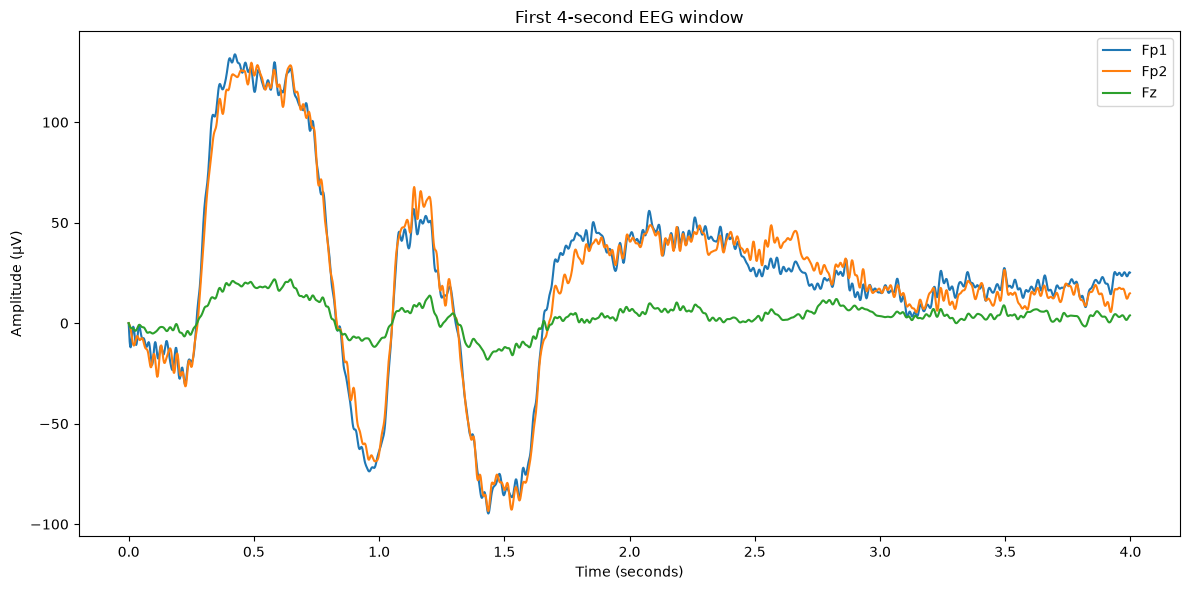

In [18]:
time = np.arange(WINDOW_SAMPLES) / filtered.info["sfreq"]

plt.figure(figsize=(12, 6))

for i, ch in enumerate(TARGET_CHANNELS):
    plt.plot(
        time,
        first_window[i] * 1e6,
        label=ch
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("First 4-second EEG window")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
window_stats = []

for idx, window in enumerate(windows):

    stats = {
        "window": idx,
        "Fp1_ptp_uv": np.ptp(window[0]) * 1e6,
        "Fp2_ptp_uv": np.ptp(window[1]) * 1e6,
        "Fz_ptp_uv": np.ptp(window[2]) * 1e6,
    }

    window_stats.append(stats)

window_df = pd.DataFrame(window_stats)

window_df.head()

,window,Fp1_ptp_uv,Fp2_ptp_uv,Fz_ptp_uv
0,0,228.516809,223.136695,39.977176
1,1,75.716027,62.687595,19.883131
2,2,157.258854,91.473769,23.451132
3,3,79.967925,76.340469,18.989456
4,4,36.905359,41.245045,14.624960


In [20]:
window_df.describe()

,window,Fp1_ptp_uv,Fp2_ptp_uv,Fz_ptp_uv
count,75.000000,75.000000,75.000000,75.000000
mean,37.000000,56.559024,47.401312,18.182958
std,21.794495,31.065065,26.539911,4.047680
min,0.000000,27.312954,26.499979,12.224871
25%,18.500000,37.475065,35.276420,15.500759
50%,37.000000,48.865554,41.746438,17.768385
75%,55.500000,61.947207,47.000109,21.119056
max,74.000000,228.516809,223.136695,39.977176


In [21]:
window_df.sort_values(
    "Fp1_ptp_uv",
    ascending=False
).head(10)

,window,Fp1_ptp_uv,Fp2_ptp_uv,Fz_ptp_uv
0,0,228.516809,223.136695,39.977176
2,2,157.258854,91.473769,23.451132
14,14,149.420603,100.169835,20.627734
12,12,110.716220,29.639839,21.826566
20,20,104.130710,47.220930,17.646120
17,17,92.947222,44.835762,19.965072
73,73,88.288797,39.864878,20.274757
3,3,79.967925,76.340469,18.989456
1,1,75.716027,62.687595,19.883131
16,16,74.470278,46.240640,21.469949


In [ ]:
window_df.sort_values(
    "Fp2_ptp_uv",
    ascending=False
).head(10)

,window,Fp1_ptp_uv,Fp2_ptp_uv,Fz_ptp_uv
0,0,228.516809,223.136695,39.977176
41,41,44.165451,134.888093,19.750818
14,14,149.420603,100.169835,20.627734
2,2,157.258854,91.473769,23.451132
3,3,79.967925,76.340469,18.989456
42,42,48.865554,72.679396,21.812831
1,1,75.716027,62.687595,19.883131
11,11,48.087841,61.818592,14.789213
22,22,70.004725,61.605244,17.422674
47,47,58.115437,57.850616,21.270561


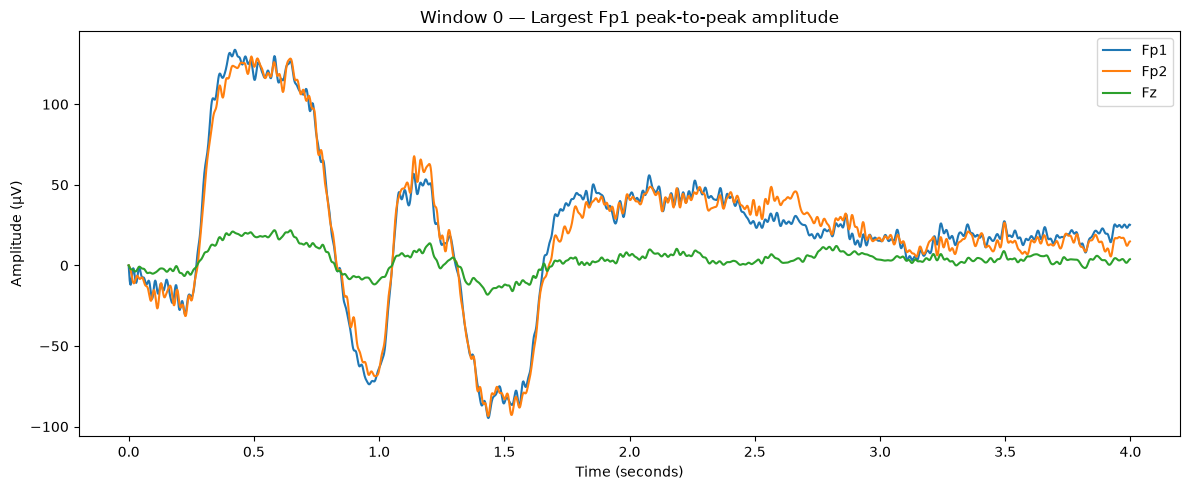

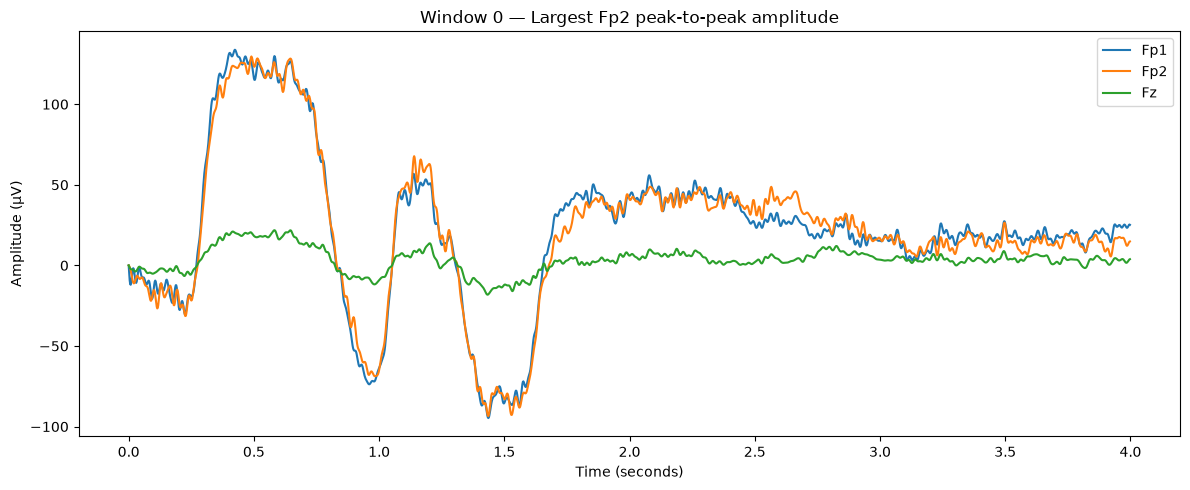

In [26]:
# Time axis for one 4-second window
time = np.arange(WINDOW_SAMPLES) / filtered.info["sfreq"]

# -------------------------
# Worst Fp1 window
# -------------------------
worst_fp1 = int(
    window_df.loc[window_df["Fp1_ptp_uv"].idxmax(), "window"]
)

plt.figure(figsize=(12, 5))

for i, ch in enumerate(TARGET_CHANNELS):
    plt.plot(time, windows[worst_fp1, i] * 1e6, label=ch)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title(f"Window {worst_fp1} — Largest Fp1 peak-to-peak amplitude")
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------
# Worst Fp2 window
# -------------------------
worst_fp2 = int(
    window_df.loc[window_df["Fp2_ptp_uv"].idxmax(), "window"]
)

plt.figure(figsize=(12, 5))

for i, ch in enumerate(TARGET_CHANNELS):
    plt.plot(time, windows[worst_fp2, i] * 1e6, label=ch)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title(f"Window {worst_fp2} — Largest Fp2 peak-to-peak amplitude")
plt.legend()
plt.tight_layout()
plt.show()

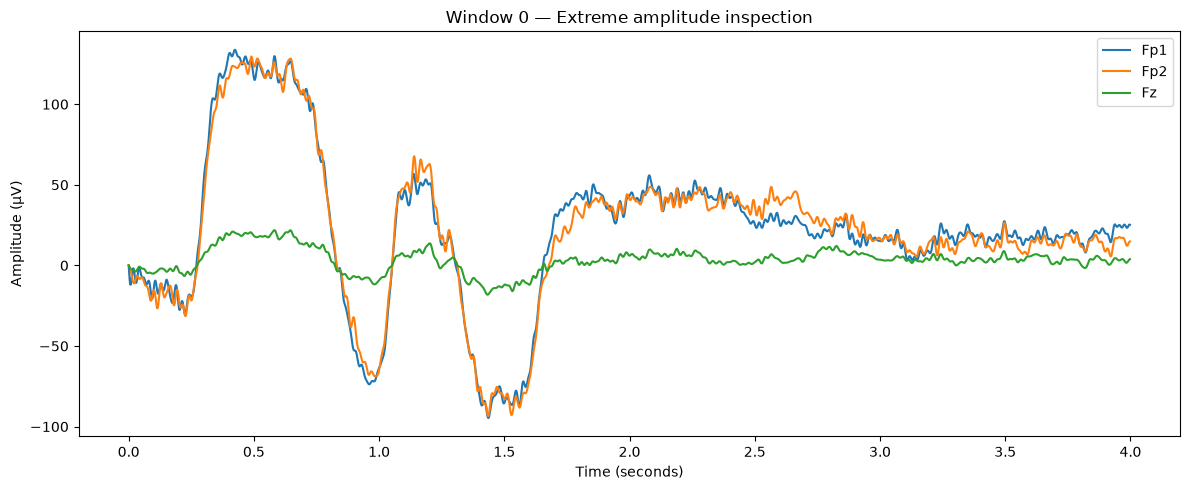

In [27]:
idx = 0

plt.figure(figsize=(12, 5))

for i, ch in enumerate(TARGET_CHANNELS):
    plt.plot(time, windows[idx, i] * 1e6, label=ch)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("Window 0 — Extreme amplitude inspection")
plt.legend()
plt.tight_layout()
plt.show()

**Window-level QC**

In [28]:
# -------------------------
# Window-level QC
# -------------------------

AMP_THRESHOLD_UV = 100.0

qc_rows = []

for idx, window in enumerate(windows):

    # Convert to microvolts
    window_uv = window * 1e6

    # Basic checks
    has_nan_inf = not np.isfinite(window_uv).all()

    # Channel statistics
    ptp = np.ptp(window_uv, axis=1)
    std = np.std(window_uv, axis=1)

    # Gross artifact detection
    frontal_artifact = (
        ptp[0] > AMP_THRESHOLD_UV or   # Fp1
        ptp[1] > AMP_THRESHOLD_UV      # Fp2
    )

    # Flatline detection
    flatline = np.any(std < 0.1)

    reject = (
        has_nan_inf or
        frontal_artifact or
        flatline
    )

    qc_rows.append({
        "window": idx,
        "Fp1_ptp_uv": ptp[0],
        "Fp2_ptp_uv": ptp[1],
        "Fz_ptp_uv": ptp[2],
        "Fp1_std_uv": std[0],
        "Fp2_std_uv": std[1],
        "Fz_std_uv": std[2],
        "has_nan_inf": has_nan_inf,
        "frontal_artifact": frontal_artifact,
        "flatline": flatline,
        "reject": reject
    })

qc_df = pd.DataFrame(qc_rows)

print(qc_df.head())

   window  Fp1_ptp_uv  Fp2_ptp_uv  Fz_ptp_uv  Fp1_std_uv  Fp2_std_uv  \
0       0  228.516809  223.136695  39.977176   47.168315   46.703836   
1       1   75.716027   62.687595  19.883131   17.180339   13.673662   
2       2  157.258854   91.473769  23.451132   33.996634   20.062701   
3       3   79.967925   76.340469  18.989456   16.824264   17.405347   
4       4   36.905359   41.245045  14.624960    7.227315    7.295080   

   Fz_std_uv  has_nan_inf  frontal_artifact  flatline  reject  
0   7.481687        False              True     False    True  
1   3.862293        False             False     False   False  
2   5.044109        False              True     False    True  
3   3.182703        False             False     False   False  
4   2.950669        False             False     False   False  


In [29]:
print("Total windows:", len(qc_df))
print("Rejected windows:", qc_df["reject"].sum())
print("Accepted windows:", (~qc_df["reject"]).sum())
print("Rejection rate:", qc_df["reject"].mean() * 100, "%")

Total windows: 75
Rejected windows: 6
Accepted windows: 69
Rejection rate: 8.0 %


In [30]:
qc_df[qc_df["reject"]]

,window,Fp1_ptp_uv,Fp2_ptp_uv,Fz_ptp_uv,Fp1_std_uv,Fp2_std_uv,Fz_std_uv,has_nan_inf,frontal_artifact,flatline,reject
0,0,228.516809,223.136695,39.977176,47.168315,46.703836,7.481687,False,True,False,True
2,2,157.258854,91.473769,23.451132,33.996634,20.062701,5.044109,False,True,False,True
12,12,110.716220,29.639839,21.826566,23.344411,5.580117,4.134180,False,True,False,True
14,14,149.420603,100.169835,20.627734,40.422000,20.457679,4.524339,False,True,False,True
20,20,104.130710,47.220930,17.646120,25.311570,8.995280,4.151847,False,True,False,True
41,41,44.165451,134.888093,19.750818,9.868703,31.553860,3.776430,False,True,False,True


In [31]:
print(
    qc_df[
        ["Fp1_ptp_uv", "Fp2_ptp_uv", "Fz_ptp_uv"]
    ].describe()
)

       Fp1_ptp_uv  Fp2_ptp_uv  Fz_ptp_uv
count   75.000000   75.000000  75.000000
mean    56.559024   47.401312  18.182958
std     31.065065   26.539911   4.047680
min     27.312954   26.499979  12.224871
25%     37.475065   35.276420  15.500759
50%     48.865554   41.746438  17.768385
75%     61.947207   47.000109  21.119056
max    228.516809  223.136695  39.977176


In [32]:
print(
    qc_df["reject"].value_counts()
)

reject
False    69
True      6
Name: count, dtype: int64
